In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("Dataset.csv",index_col=0)
df.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTGS,ATGS,HTGC,ATGC,...,HTLossStreak3,HTLossStreak5,ATWinStreak3,ATWinStreak5,ATLossStreak3,ATLossStreak5,HTGD,ATGD,DiffPts,DiffFormPts
0,01/10/00,Arsenal,Man United,1,0,H,13,20,9,7,...,0,0,0,0,0,0,0.5000,1.625,-0.3750,-0.2500
1,01/10/00,Chelsea,Liverpool,3,0,H,10,12,12,10,...,0,0,0,0,0,0,-0.2500,0.250,-0.6250,-0.6250
2,01/10/00,Sunderland,Leicester,0,0,NH,7,7,11,2,...,0,0,0,0,0,0,-0.5000,0.625,-0.8750,-0.7500
3,02/12/00,Aston Villa,Newcastle,1,1,NH,18,17,13,15,...,0,0,0,0,0,0,0.3125,0.125,0.0625,0.0625
4,02/12/00,Bradford,Coventry,2,1,H,7,14,24,30,...,0,0,0,0,1,0,-1.0625,-1.000,-0.2500,0.0625


In [4]:
df.shape

(5489, 39)

In [5]:
df["FTR"].value_counts()

FTR
NH    3183
H     2306
Name: count, dtype: int64

In [6]:
# Changing Date Column from String to Date Datatype...
# Separating Categorical and Numerical Columns...

df['Date']=pd.to_datetime(df['Date'],dayfirst=True,format="mixed")
df_categorical=df.select_dtypes(exclude="number")
df_numerical=df.select_dtypes(include="number")

In [7]:
# Cleaning and Preprocessing Numerical Columns...
df_numerical.describe()

,FTHG,FTAG,HTGS,ATGS,HTGC,ATGC,HTP,ATP,MW,HTFormPts,...,HTLossStreak3,HTLossStreak5,ATWinStreak3,ATWinStreak5,ATLossStreak3,ATLossStreak5,HTGD,ATGD,DiffPts,DiffFormPts
count,5489.000000,5489.000000,5489.000000,5489.000000,5489.000000,5489.000000,5489.000000,5489.000000,5489.000000,5489.000000,...,5489.000000,5489.000000,5489.000000,5489.000000,5489.000000,5489.000000,5489.000000,5489.000000,5489.000000,5489.000000
mean,1.470760,1.196575,24.698488,24.849882,24.471671,24.245036,1.218747,1.240148,19.555110,6.274731,...,0.058845,0.014757,0.065404,0.018218,0.050282,0.010384,0.005851,0.035067,-0.021401,-0.019878
std,1.310111,1.156716,17.427055,17.409315,16.380786,16.300105,0.536293,0.532578,10.976698,3.603269,...,0.235356,0.120589,0.247259,0.133752,0.218547,0.101383,0.704248,0.708678,0.688609,0.417171
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-3.000000,-3.333333,-2.363636,-2.250000
25%,0.000000,0.000000,11.000000,11.000000,11.000000,11.000000,0.888889,0.909091,10.000000,4.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.500000,-0.459459,-0.500000,-0.181818
50%,1.000000,1.000000,23.000000,23.000000,23.000000,23.000000,1.178571,1.200000,20.000000,6.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.058824,0.000000,0.000000,0.000000
75%,2.000000,2.000000,35.000000,36.000000,36.000000,36.000000,1.571429,1.588235,29.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.428571,0.500000,0.444444,0.157895
max,9.000000,7.000000,102.000000,105.000000,85.000000,82.000000,2.736842,2.761905,38.000000,15.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.000000,3.500000,2.285714,2.250000


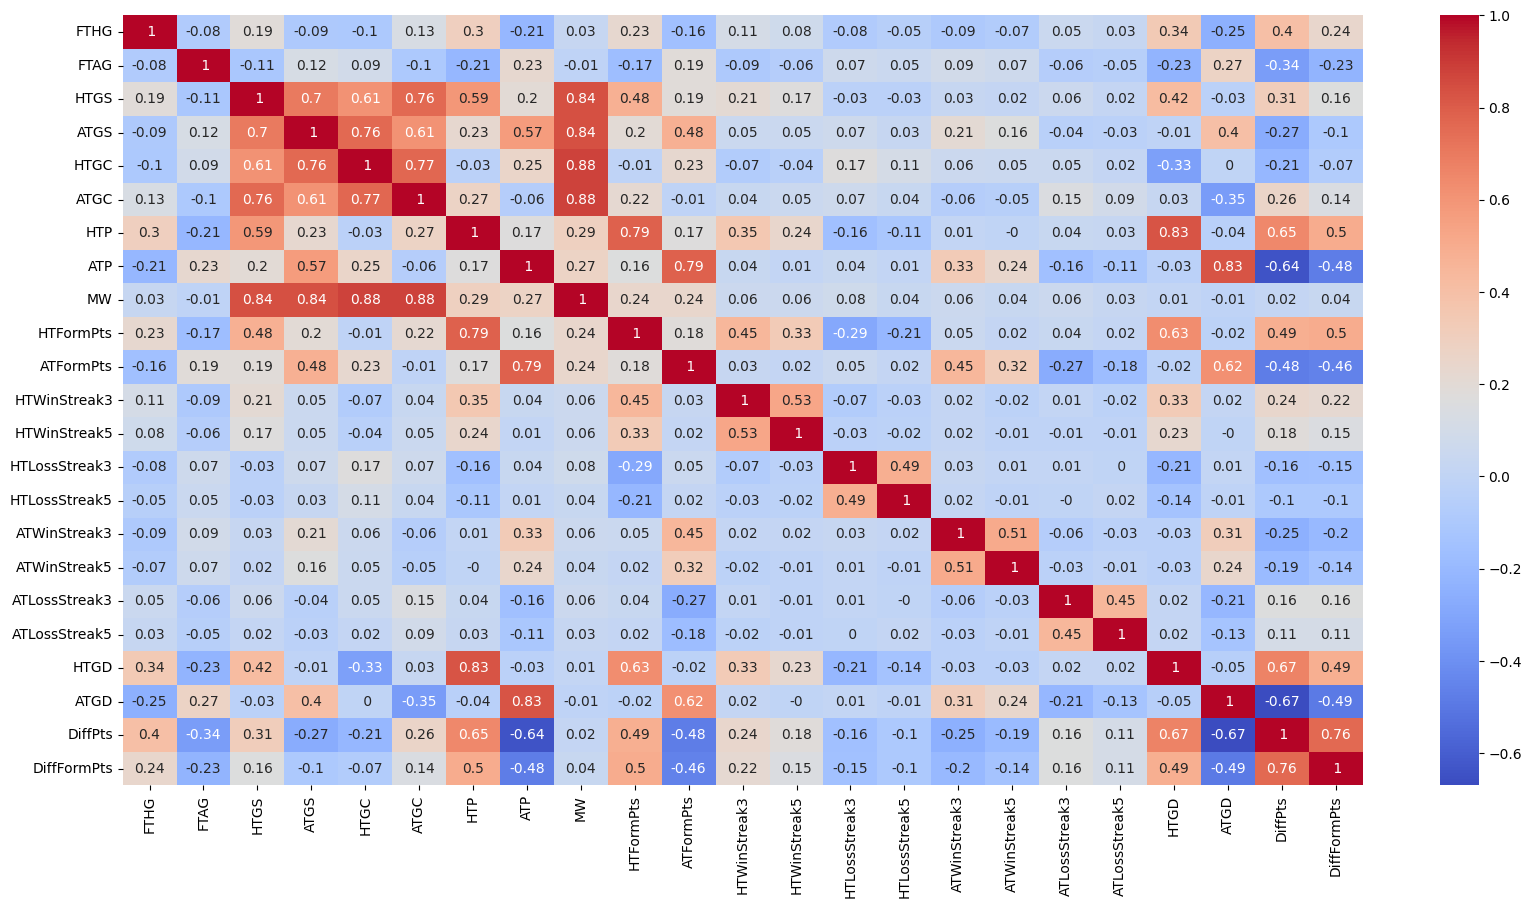

In [8]:
plt.figure(figsize=(20,10))
sns.heatmap(df_numerical.corr().round(2),annot=True,fmt="2g",cmap="coolwarm")
plt.show()

In [9]:
# Dropping Unwanted and Useless Columns...
# ["FTHG","FTAG"] Obviously Dropping Score Columns after Match...
# ["HTP","ATP"] Shows same Info as ["HTGS","ATGS"]...
# ["HTGD","ATGD"] Shows same Info as ["DiffPts"]...
# ["MW"] I think MW is not that Useful...
# ["HTFormPts","ATFormPts","DiffFormPts"] Corelates with the Upcoming 4 Columns...
df_numerical.drop(columns=["FTHG","FTAG","HTP","ATP","HTGD","ATGD","HTFormPts","ATFormPts","DiffFormPts","MW"],inplace=True)

# Combining Similar Columns to Efficiently Reduce the Number of Columns...
df_numerical["Current_HT_Streak"]=np.where(df_numerical["HTWinStreak5"],5,np.where(df_numerical["HTWinStreak3"],3,0))
df_numerical["Current_HT_LossStreak"]=np.where(df_numerical["HTLossStreak5"],5,np.where(df_numerical["HTLossStreak3"],3,0))
df_numerical["Current_AT_Streak"]=np.where(df_numerical["ATWinStreak5"],5,np.where(df_numerical["ATWinStreak3"],3,0))
df_numerical["Current_AT_LossStreak"]=np.where(df_numerical["ATLossStreak5"],5,np.where(df_numerical["ATLossStreak3"],3,0))

# Dropping Combined Columns...
df_numerical.drop(columns=["HTWinStreak5","HTWinStreak3","HTLossStreak5","HTLossStreak3","ATWinStreak5","ATWinStreak3","ATLossStreak5","ATLossStreak3"],inplace=True)

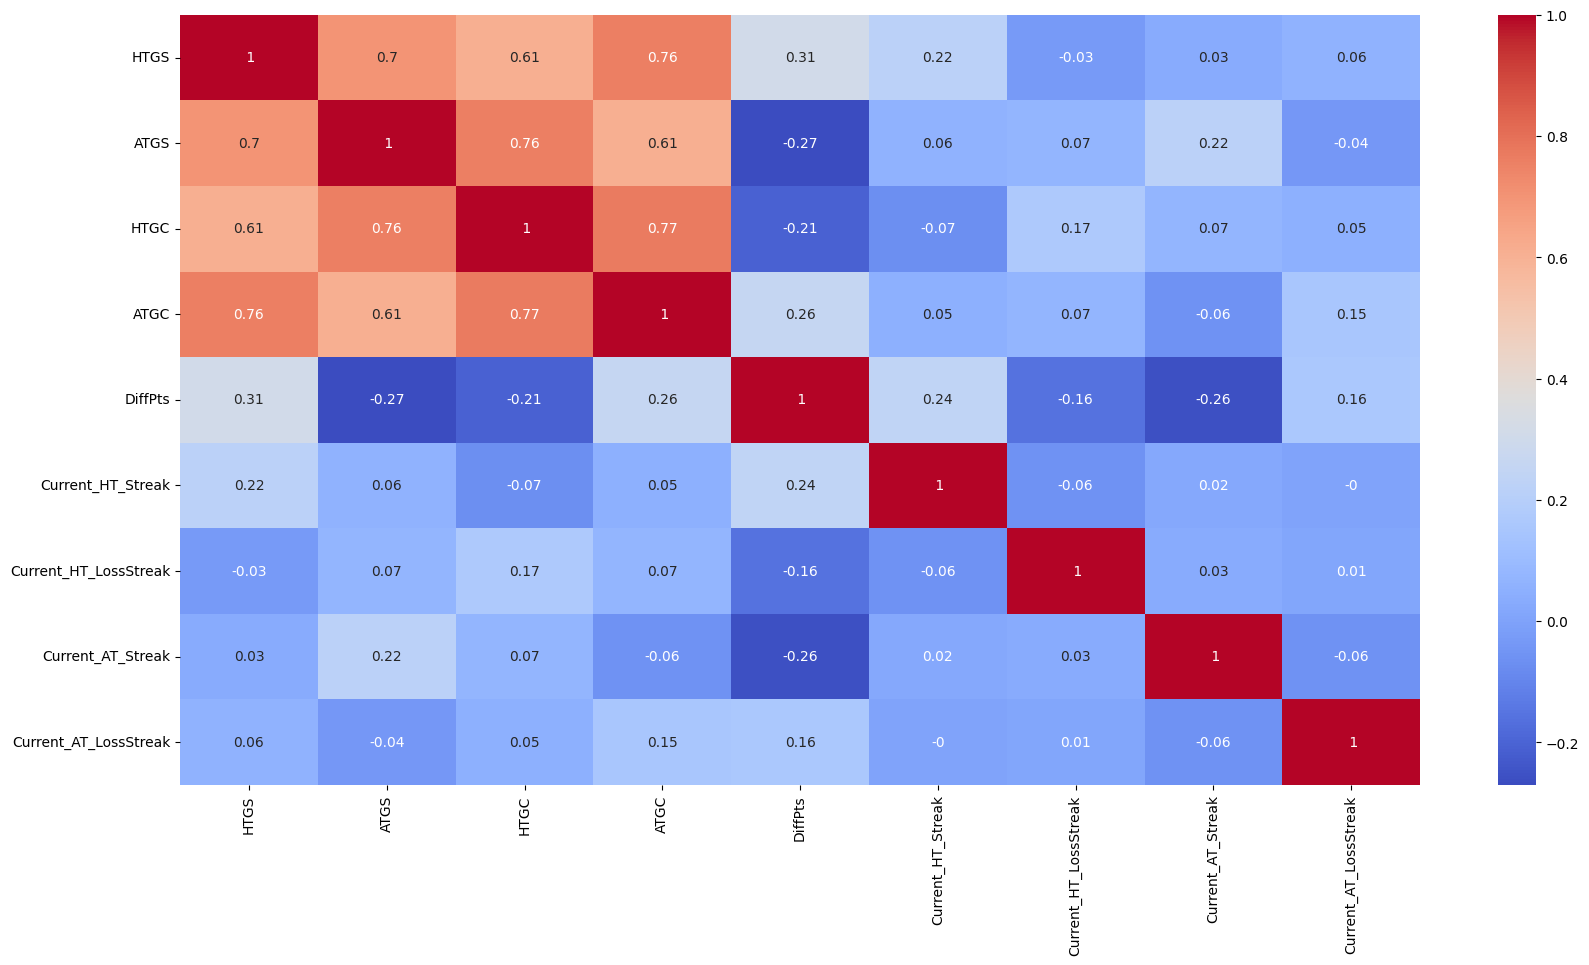

In [10]:
plt.figure(figsize=(20,10))
sns.heatmap(df_numerical.corr().round(2),annot=True,fmt="2g",cmap="coolwarm")
plt.show()

In [11]:
df_numerical.describe()

,HTGS,ATGS,HTGC,ATGC,DiffPts,Current_HT_Streak,Current_HT_LossStreak,Current_AT_Streak,Current_AT_LossStreak
count,5489.000000,5489.000000,5489.000000,5489.000000,5489.000000,5489.000000,5489.000000,5489.000000,5489.000000
mean,24.698488,24.849882,24.471671,24.245036,-0.021401,0.228457,0.206048,0.232647,0.171616
std,17.427055,17.409315,16.380786,16.300105,0.688609,0.905071,0.850523,0.908928,0.767690
min,0.000000,0.000000,0.000000,0.000000,-2.363636,0.000000,0.000000,0.000000,0.000000
25%,11.000000,11.000000,11.000000,11.000000,-0.500000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,23.000000,23.000000,23.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,35.000000,36.000000,36.000000,36.000000,0.444444,0.000000,0.000000,0.000000,0.000000
max,102.000000,105.000000,85.000000,82.000000,2.285714,5.000000,5.000000,5.000000,5.000000


In [12]:
df_numerical.columns

Index(['HTGS', 'ATGS', 'HTGC', 'ATGC', 'DiffPts', 'Current_HT_Streak',
       'Current_HT_LossStreak', 'Current_AT_Streak', 'Current_AT_LossStreak'],
      dtype='object')

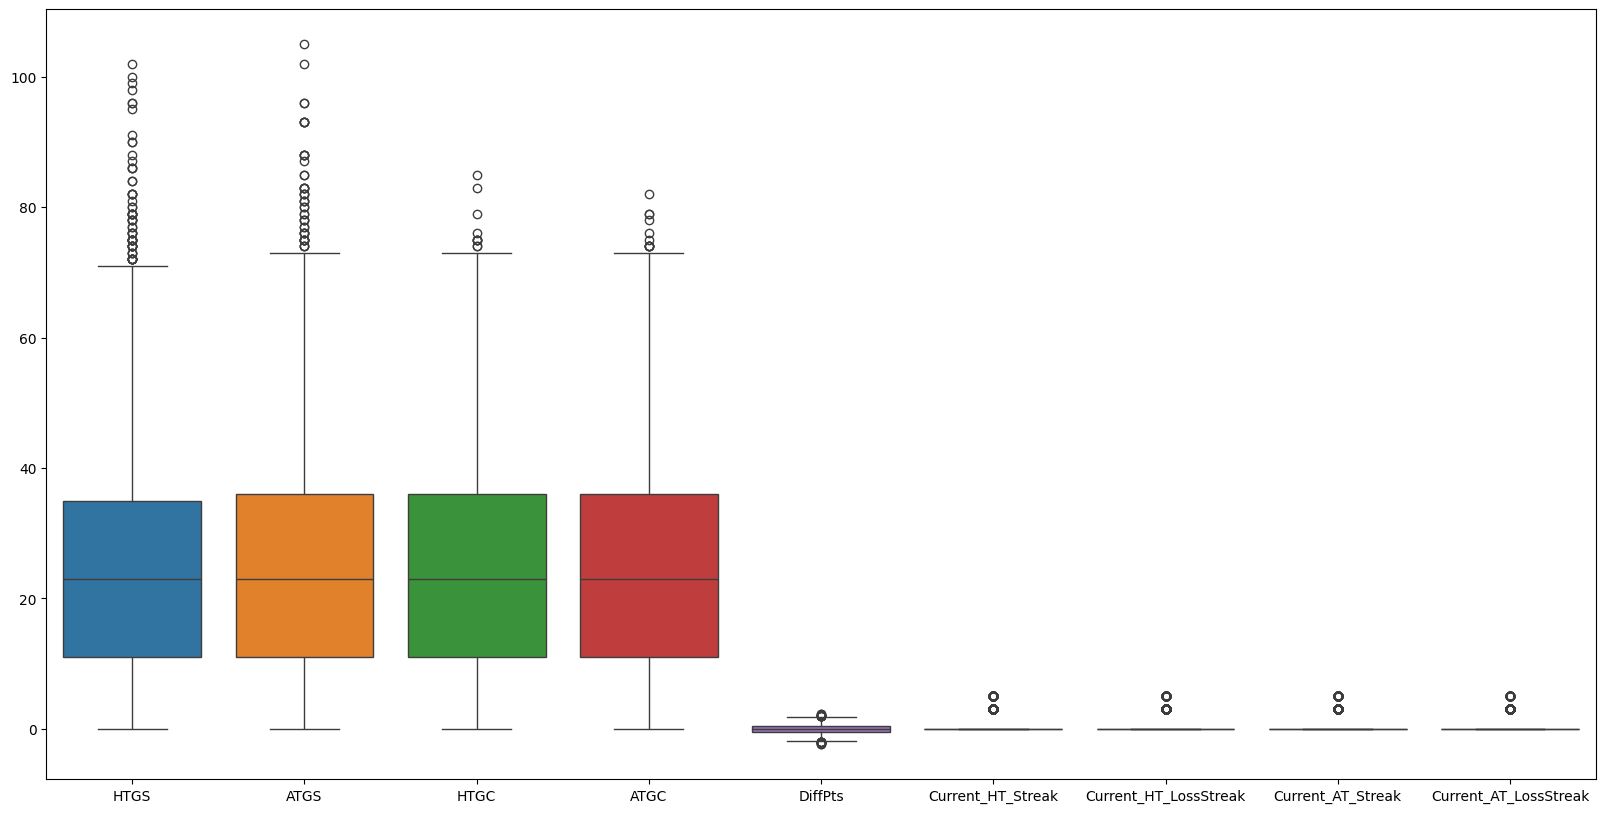

In [13]:
# Detecting any Outliers if they Exist...
plt.figure(figsize=(20,10))
sns.boxplot(df_numerical)
plt.show()

In [14]:
# These are Actually not Outliers, 
# but Some of the Teams who Survived on Top till the End of the Season, 
# with Increased Goal Scores through the Season Weeks...

# Similarly Some Teams are Performing really Poor throughout the Season,
# with Decreased Goal Scores or Increased Goals Conceded through the Season Weeks...

In [15]:
import math
def Plot_Histgrams(data,columns):
    n_cols=2
    n_rows=math.ceil(len(columns)/n_cols)
    
    plt.figure(figsize=(12,4*n_rows))
    for i,col in enumerate(columns,1):
        plt.subplot(n_rows,n_cols,i)
        sns.histplot(data[col],kde=True,bins=20,color='royalblue')
        plt.title(f'Distribution of {col}',fontsize=12)
        plt.xlabel(col)
        plt.ylabel('Count (Frequency)')
        
    plt.tight_layout()
    plt.show()

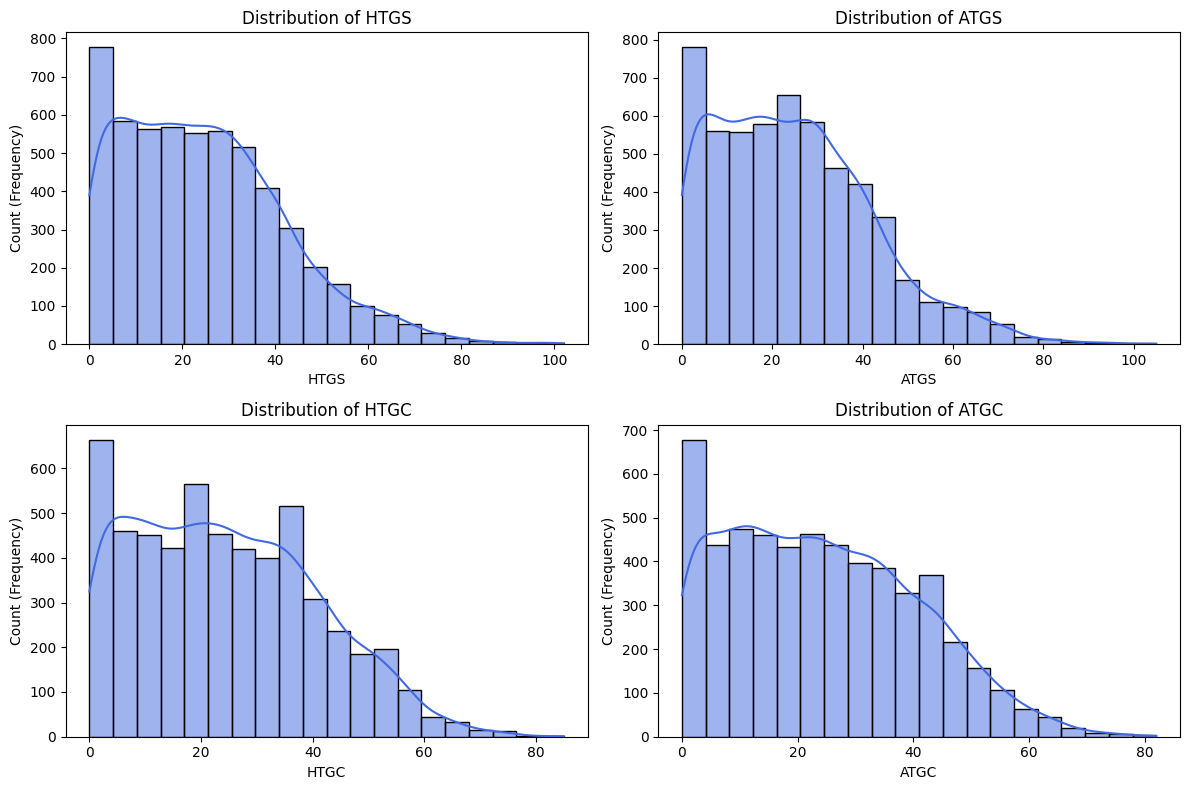

In [16]:
Plot_Histgrams(df_numerical,['HTGS','ATGS','HTGC','ATGC'])

In [17]:
# Cleaning and Preprocessing Categorical Columns...
df_categorical.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5489 entries, 0 to 5488
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          5489 non-null   datetime64[ns]
 1   HomeTeam      5489 non-null   object        
 2   AwayTeam      5489 non-null   object        
 3   FTR           5489 non-null   object        
 4   HM1           5489 non-null   object        
 5   HM2           5489 non-null   object        
 6   HM3           5489 non-null   object        
 7   HM4           5489 non-null   object        
 8   HM5           5489 non-null   object        
 9   AM1           5489 non-null   object        
 10  AM2           5489 non-null   object        
 11  AM3           5489 non-null   object        
 12  AM4           5489 non-null   object        
 13  AM5           5489 non-null   object        
 14  HTFormPtsStr  5489 non-null   object        
 15  ATFormPtsStr  5489 non-null   object       

In [18]:
# Dropping Unnecessary Columns...
# ["HTFormPtsStr","ATFormPtsStr","HM1","HM2","HM3","HM4","HM5","AM1","AM2","AM3","AM4","AM5"] this Information is Already Present in Numerical Data...
df_categorical.drop(columns=["HTFormPtsStr","ATFormPtsStr",
                             "HM1","HM2","HM3","HM4","HM5",
                             "AM1","AM2","AM3","AM4","AM5"],inplace=True)
df_categorical.head()

,Date,HomeTeam,AwayTeam,FTR
0,2000-10-01,Arsenal,Man United,H
1,2000-10-01,Chelsea,Liverpool,H
2,2000-10-01,Sunderland,Leicester,NH
3,2000-12-02,Aston Villa,Newcastle,NH
4,2000-12-02,Bradford,Coventry,H


In [19]:
df_categorical["FTR"]=np.where(df_categorical["FTR"]=="H",1,0)
df_categorical.head()

,Date,HomeTeam,AwayTeam,FTR
0,2000-10-01,Arsenal,Man United,1
1,2000-10-01,Chelsea,Liverpool,1
2,2000-10-01,Sunderland,Leicester,0
3,2000-12-02,Aston Villa,Newcastle,0
4,2000-12-02,Bradford,Coventry,1


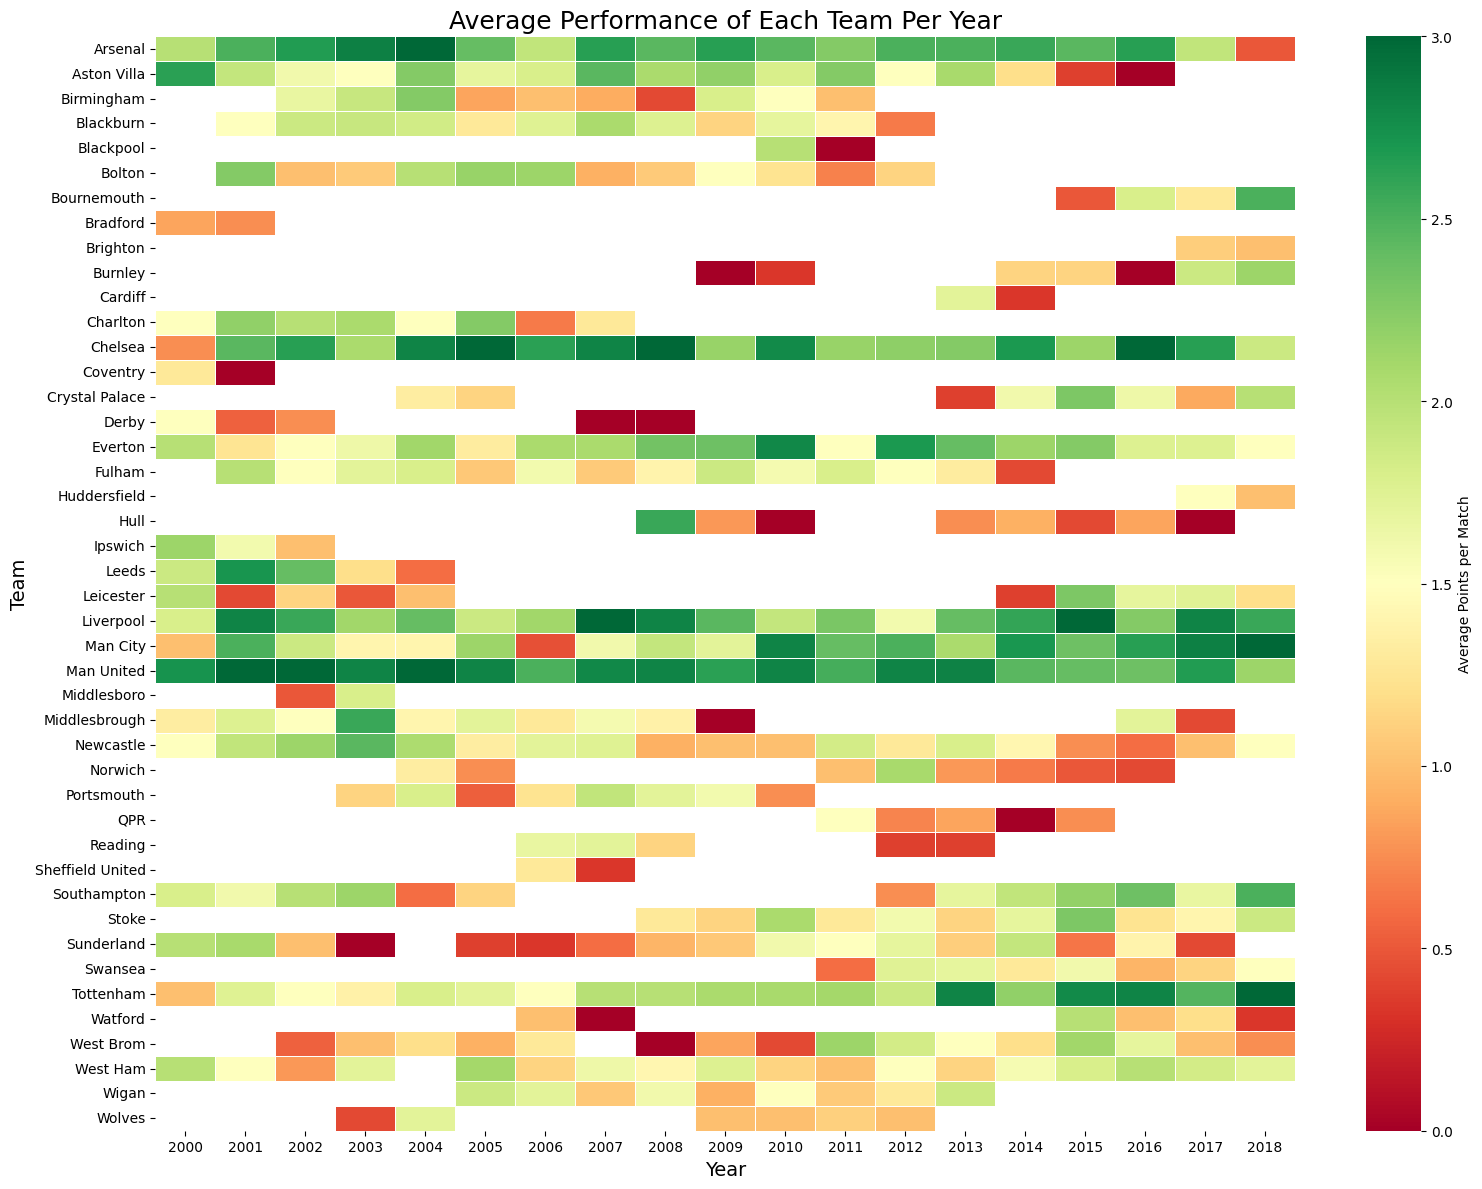

In [20]:
# Performance of Teams through out Years as Home Team and Away Team...

df_categorical['Year']=df['Date'].dt.year
df_categorical['HomePts']=np.where(df_categorical['FTR']==1,3,np.where(df['FTR']==0,1,0))
df_categorical['AwayPts']=np.where(df_categorical['FTR']==0,3,np.where(df['FTR']==1,1,0))

#home_data=df_categorical[['Year','HomeTeam','HomePts']].rename(columns={'HomeTeam':'Team','HomePts':'Points'})
away_data=df_categorical[['Year','AwayTeam','AwayPts']].rename(columns={'AwayTeam':'Team','AwayPts':'Points'})
#all_matches=pd.concat([home_data,away_data])
all_matches=away_data
avg_performance=all_matches.groupby(['Team', 'Year'])['Points'].mean().reset_index()
pivot_table=avg_performance.pivot(index='Team',columns='Year',values='Points')
plt.figure(figsize=(16,12))
sns.heatmap(pivot_table,cmap='RdYlGn',linewidths=0.5,cbar_kws={'label':'Average Points per Match'})

plt.title('Average Performance of Each Team Per Year',fontsize=18)
plt.xlabel('Year',fontsize=14)
plt.ylabel('Team',fontsize=14)
plt.tight_layout()
plt.show()

In [21]:
# Combining the Categorical and Numerical Data...
X=pd.concat([df_categorical.drop(columns=["Date","HomePts","AwayPts"]),df_numerical],axis=1)
X.columns

Index(['HomeTeam', 'AwayTeam', 'FTR', 'Year', 'HTGS', 'ATGS', 'HTGC', 'ATGC',
       'DiffPts', 'Current_HT_Streak', 'Current_HT_LossStreak',
       'Current_AT_Streak', 'Current_AT_LossStreak'],
      dtype='object')

In [22]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5489 entries, 0 to 5488
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   HomeTeam               5489 non-null   object 
 1   AwayTeam               5489 non-null   object 
 2   FTR                    5489 non-null   int64  
 3   Year                   5489 non-null   int32  
 4   HTGS                   5489 non-null   int64  
 5   ATGS                   5489 non-null   int64  
 6   HTGC                   5489 non-null   int64  
 7   ATGC                   5489 non-null   int64  
 8   DiffPts                5489 non-null   float64
 9   Current_HT_Streak      5489 non-null   int64  
 10  Current_HT_LossStreak  5489 non-null   int64  
 11  Current_AT_Streak      5489 non-null   int64  
 12  Current_AT_LossStreak  5489 non-null   int64  
dtypes: float64(1), int32(1), int64(9), object(2)
memory usage: 578.9+ KB


In [23]:
X_train=X[(X["Year"]!=2017) & (X["Year"]!=2018)]
X_test=X[(X["Year"]==2017) | (X["Year"]==2018)]
Y_train=X[(X["Year"]!=2017) & (X["Year"]!=2018)]["FTR"]
Y_test=X[(X["Year"]==2017) | (X["Year"]==2018)]["FTR"]

print("Shape of X_train:",X_train.shape)
print("Shape of Y_train:",Y_train.shape)
print("Shape of X_test:",X_test.shape)
print("Shape of Y_test:",Y_test.shape)

Shape of X_train: (5019, 13)
Shape of Y_train: (5019,)
Shape of X_test: (470, 13)
Shape of Y_test: (470,)


In [24]:
def Get_Team_Performance_History(df,TN,HT=True):
    """
    Takes a team name and whether they are playing at Home or Away,
    and returns a historical performance score between 0 and 100.
    """
    if HT:
        team_df=df[df['HomeTeam']==TN].copy()
        if team_df.empty:
            return 50.0
        
        # Win Rate...
        wins=len(team_df[team_df['FTR']==1])
        total_matches=len(team_df)
        win_score=(wins/total_matches)*100
        
        # Goal Efficiency...
        total_gs=team_df['HTGS'].mean()
        total_gc=team_df['HTGC'].mean()
        if (total_gs+total_gc)==0:
            goal_score=50
        else:
            goal_score=(total_gs/(total_gs+total_gc))*100
            
        # Stability
        numberof3streaks=len(team_df[team_df['Current_HT_Streak']==3])
        numberof5streaks=len(team_df[team_df['Current_HT_Streak']==5])
        streakscore=(0.4*numberof3streaks)+(0.6*numberof5streaks)
        
    else:
        team_df=df[df['AwayTeam']==TN].copy()
        if team_df.empty:
            return 50.0
        
        wins=len(team_df[team_df['FTR']==0])
        total_matches=len(team_df)
        win_score=(wins/total_matches)*100

        total_gs=team_df['ATGS'].mean()
        total_gc=team_df['ATGC'].mean()
        if (total_gs+total_gc)==0:
            goal_score=50
        else:
            goal_score=(total_gs/(total_gs+total_gc))*100

        numberof3streaks=len(team_df[team_df['Current_AT_Streak']==3])
        numberof5streaks=len(team_df[team_df['Current_AT_Streak']==5])
        streakscore=(0.4*numberof3streaks)+(0.6*numberof5streaks)

    # 50% Win Record + 30% Goal Efficiency + 20% Stability
    final_score=(0.50*win_score)+(0.30*goal_score)+(0.20*streakscore)
    final_score=max(0,min(100,final_score))
    return round(final_score,2)



HTDict={}
for i in df['HomeTeam'].unique():
    HTDict[i]=Get_Team_Performance_History(X_train,i,HT=True)
    
ATDict={}
for i in df['AwayTeam'].unique():
    ATDict[i]=Get_Team_Performance_History(X_train,i,HT=False)
    
X_train['HomeTeam']=X_train['HomeTeam'].apply(lambda x: HTDict[x])
X_train['AwayTeam']=X_train['AwayTeam'].apply(lambda x: ATDict[x])
X_train.drop(["FTR","Year"],axis=1,inplace=True)
    
X_test['HomeTeam']=X_test['HomeTeam'].apply(lambda x: HTDict[x])
X_test['AwayTeam']=X_test['AwayTeam'].apply(lambda x: ATDict[x])
X_test.drop(["FTR","Year"],axis=1,inplace=True)

# df['PerformanceScore']=(df['HomeTeamPerformance']+df['AwayTeamPerformance'])/2
# df['PerformanceScore'].mean()

C:\Users\siddh\AppData\Local\Temp\ipykernel_18848\3184378379.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['HomeTeam']=X_train['HomeTeam'].apply(lambda x: HTDict[x])
C:\Users\siddh\AppData\Local\Temp\ipykernel_18848\3184378379.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['AwayTeam']=X_train['AwayTeam'].apply(lambda x: ATDict[x])
C:\Users\siddh\AppData\Local\Temp\ipykernel_18848\3184378379.py:66: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a D

In [25]:
X_train.columns

Index(['HomeTeam', 'AwayTeam', 'HTGS', 'ATGS', 'HTGC', 'ATGC', 'DiffPts',
       'Current_HT_Streak', 'Current_HT_LossStreak', 'Current_AT_Streak',
       'Current_AT_LossStreak'],
      dtype='object')

In [26]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5019 entries, 0 to 5018
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   HomeTeam               5019 non-null   float64
 1   AwayTeam               5019 non-null   float64
 2   HTGS                   5019 non-null   int64  
 3   ATGS                   5019 non-null   int64  
 4   HTGC                   5019 non-null   int64  
 5   ATGC                   5019 non-null   int64  
 6   DiffPts                5019 non-null   float64
 7   Current_HT_Streak      5019 non-null   int64  
 8   Current_HT_LossStreak  5019 non-null   int64  
 9   Current_AT_Streak      5019 non-null   int64  
 10  Current_AT_LossStreak  5019 non-null   int64  
dtypes: float64(3), int64(8)
memory usage: 470.5 KB


In [27]:
# Starting Training with 5 Classification Models...

from sklearn.preprocessing import StandardScaler

#
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report

In [28]:
Scaler=StandardScaler()
X_train_transformed=Scaler.fit_transform(X_train)
X_train=pd.DataFrame(X_train_transformed,columns=X_train.columns)

X_test_transformed=Scaler.transform(X_test)
X_test=pd.DataFrame(X_test_transformed,columns=X_train.columns)


In [29]:
Model=LogisticRegression()
Model.fit(X_train_transformed,Y_train)
print("Score on Training Data:",Model.score(X_train_transformed,Y_train))
print("Score on Testing Data:",Model.score(X_test_transformed,Y_test))
Y_pred=Model.predict(X_test_transformed)
print(classification_report(Y_test,Y_pred))

Score on Training Data: 0.771667662881052
Score on Testing Data: 0.7574468085106383
              precision    recall  f1-score   support

           0       0.77      0.82      0.79       269
           1       0.74      0.68      0.70       201

    accuracy                           0.76       470
   macro avg       0.75      0.75      0.75       470
weighted avg       0.76      0.76      0.76       470



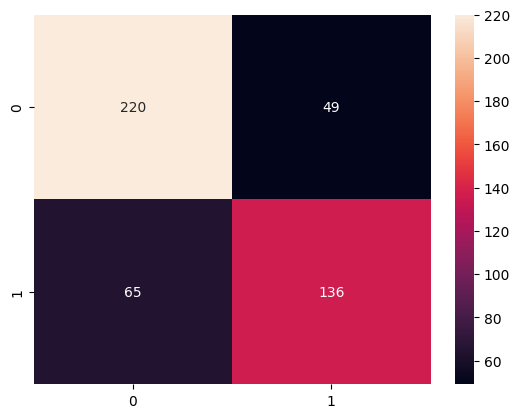

In [30]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(Y_test,Y_pred).round(2)
sns.heatmap(cm,annot=True,fmt="d")
plt.show()

In [31]:
from sklearn.ensemble import BaggingClassifier

# Ek basic Logistic Regression banayein
base_lr = LogisticRegression()
# Ab iski 50 copies banayein (Har copy 80% random data par train hogi)
bagged_lr=BaggingClassifier(estimator=base_lr, 
                              n_estimators=1000, 
                              max_samples=0.8, 
                              max_features=1.0, 
                              random_state=100)

bagged_lr.fit(X_train_transformed, Y_train)
print("Bagged LR Score:", bagged_lr.score(X_test_transformed,Y_test))

Bagged LR Score: 0.7574468085106383


In [32]:
# Model=XGBClassifier()
# Model.fit(X_train,Y_train)
# print("Score on Training Data:",Model.score(X_train,Y_train))
# print("Score on Testing Data:",Model.score(X_test,Y_test))
# Y_pred=Model.predict(X_test)
# print(classification_report(Y_test,Y_pred))

In [33]:
Model=GaussianNB()
Model.fit(X_train,Y_train)
print("Score on Training Data:",Model.score(X_train,Y_train))
print("Score on Testing Data:",Model.score(X_test,Y_test))
Y_pred=Model.predict(X_test)
print(classification_report(Y_test,Y_pred))

Score on Training Data: 0.7549312612074118
Score on Testing Data: 0.7361702127659574
              precision    recall  f1-score   support

           0       0.78      0.75      0.76       269
           1       0.68      0.72      0.70       201

    accuracy                           0.74       470
   macro avg       0.73      0.73      0.73       470
weighted avg       0.74      0.74      0.74       470



In [34]:
Model=DecisionTreeClassifier(criterion="entropy",min_samples_split=7,max_depth=8,random_state=13)
Model.fit(X_train,Y_train)
print("Score on Training Data:",Model.score(X_train,Y_train))
print("Score on Testing Data:",Model.score(X_test,Y_test))
Y_pred=Model.predict(X_test)
print(classification_report(Y_test,Y_pred))

Score on Training Data: 0.8168957959752939
Score on Testing Data: 0.7425531914893617
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       269
           1       0.72      0.64      0.68       201

    accuracy                           0.74       470
   macro avg       0.74      0.73      0.73       470
weighted avg       0.74      0.74      0.74       470



In [35]:
Scaler=StandardScaler()
X_train_transformed=Scaler.fit_transform(X_train)
X_train=pd.DataFrame(X_train_transformed,columns=X_train.columns)
X_test_transformed=Scaler.transform(X_test)
X_test=pd.DataFrame(X_test_transformed,columns=X_train.columns)


Model=RandomForestClassifier(n_estimators=200,criterion="entropy",min_samples_split=7,max_depth=8,random_state=13)
Model.fit(X_train_transformed,Y_train)
print("Score on Training Data:",Model.score(X_train_transformed,Y_train))
print("Score on Testing Data:",Model.score(X_test_transformed,Y_test))
Y_pred=Model.predict(X_test_transformed)
print(classification_report(Y_test,Y_pred))

Score on Training Data: 0.8153018529587567
Score on Testing Data: 0.7851063829787234
              precision    recall  f1-score   support

           0       0.78      0.87      0.82       269
           1       0.79      0.67      0.73       201

    accuracy                           0.79       470
   macro avg       0.79      0.77      0.78       470
weighted avg       0.79      0.79      0.78       470



In [36]:
import joblib
# Save the model and scaler
joblib.dump(Model,'random_forest_model.pkl')
joblib.dump(Scaler,'scaler.pkl')

# Save the dictionaries
joblib.dump(HTDict,'ht_dict.pkl')
joblib.dump(ATDict,'at_dict.pkl')

['at_dict.pkl']